## Imports and selection of the climate variable

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

from hostrada4py import hostradaPoint as hp

HOSTRADA_VAR = "tas" # outside air temperature
#HOSTRADA_VAR = "sfcWind" # wind speed
#HOSTRADA_VAR = "uhi" # Urban Heat Island Intensity
#HOSTRADA_VAR = "rsds" # global radiation
#HOSTRADA_VAR = "clt" # cloud cover
#HOSTRADA_VAR = "hurs" # relative humidity
#HOSTRADA_VAR = "tdew" # dew point temperature

## Definition of the location, the time period and download of the HOSTRADA values

In [ ]:
# Location in the center of Berlin: 
# Einsteinufer 43 - 53, 10587 Berlin
lon = 13.32259
lat = 52.51712

# Location in the north of Berlin: 
# Ludolfinger Platz, 13465 Berlin 
#lon = 13.28801 
#lat = 52.63248 

# Location about 80 km north of Berlin in the country side:
# Templiner Str 7., 17268 Boitzenburger Land
#lon = 13.60418
#lat = 53.26202

# Time period: entire year 2025
start_UTC = "2025-01-01T00:00"
end_UTC = "2025-12-31T23:00"

df = hp.extract_values_for_point(
    var= HOSTRADA_VAR,
    lon=lon,
    lat=lat,
    start=start_UTC,
    end=end_UTC
)

fn = "HOSTRADA_" + HOSTRADA_VAR + ".csv"
df.to_csv(fn, index=False)
print(f"{len(df)} rows written to {fn}.")


## Yearly time series of the HOSTRADA variable

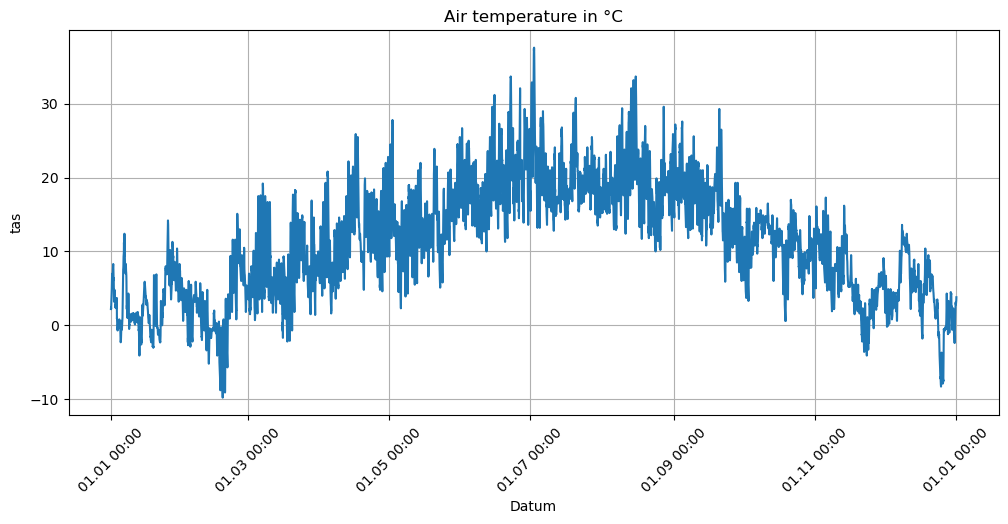

In [19]:
df = pd.read_csv(fn)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["time"], df[HOSTRADA_VAR])
ax.set_xlabel("Datum")
ax.set_ylabel(HOSTRADA_VAR)

if HOSTRADA_VAR == "tas":
    title = "Air temperature in °C"
elif HOSTRADA_VAR == "uhi":
    title = "Urban Heat Island Intensity in °C"
elif HOSTRADA_VAR == "sfcWind":
    title = "Wind speed in m/s"
elif HOSTRADA_VAR == "rsds":
    title = "Global radiation in W/m2"
elif HOSTRADA_VAR == "clt":
    title = "Cloud cover in eighth"
elif HOSTRADA_VAR == "hurs":
    title = "Relative humidity in percent"
elif HOSTRADA_VAR == "tdew":
    title = "Dew point temperature in °C"
else:
    title = "unknown"

ax.set_title(title)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## Monthly mean values of the HOSTRADA variable

/var/folders/m_/v6sg1bhx4kjc96xm8gf6bt3c0000gn/T/ipykernel_3487/1921743541.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = df.resample("M", on="time")[HOSTRADA_VAR].mean()


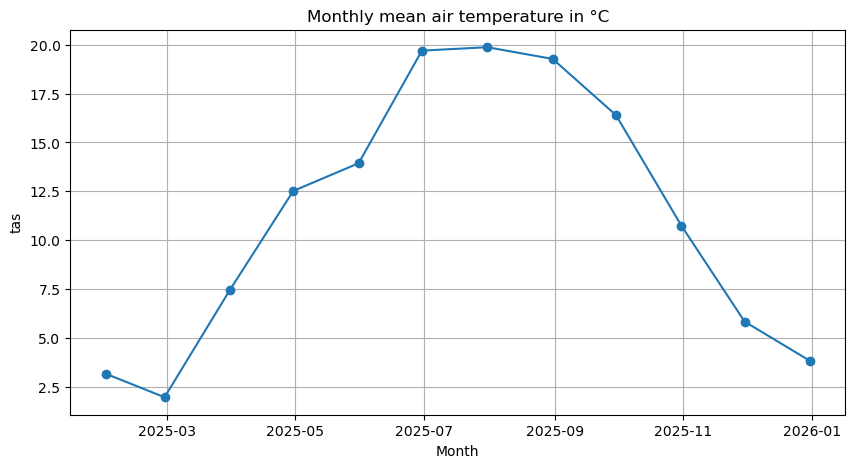

In [20]:
df = pd.read_csv(fn)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
monthly_mean = df.resample("M", on="time")[HOSTRADA_VAR].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_mean.index, monthly_mean.values, marker="o")
plt.xlabel("Month")
plt.ylabel(HOSTRADA_VAR)

if HOSTRADA_VAR == "tas":
    title = "Monthly mean air temperature in °C"
elif HOSTRADA_VAR == "uhi":
    title = "Monthly mean Urban Heat Island Intensity in °C"
elif HOSTRADA_VAR == "sfcWind":
    title = "Monthly mean wind speed in m/s"
elif HOSTRADA_VAR == "rsds":
    title = "Monthly mean global radiotion in W/m2"
elif HOSTRADA_VAR == "clt":
    title = "Monthly mean cloud cover in eighth"
elif HOSTRADA_VAR == "hurs":
    title = "Monthly mean relative humidity in percent"
elif HOSTRADA_VAR == "tdew":
    title = "Monthly mean dew point temperature in °C"
else:
    title = "unknown"
    
plt.title(title)
plt.grid(True)
plt.show()


## Heatmap of the HOSTRADA variable

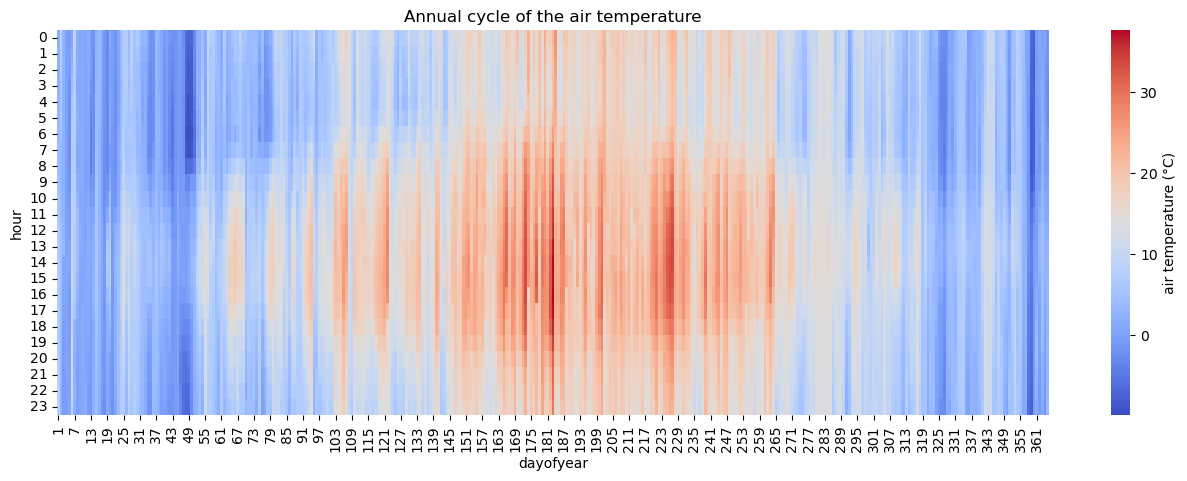

In [21]:
df["dayofyear"] = df["time"].dt.dayofyear
df["hour"] = df["time"].dt.hour
heatmap_year = df.pivot_table(
    values=HOSTRADA_VAR,
    index="hour",
    columns="dayofyear")

plt.figure(figsize=(16,5))
plt.xlabel("Tag des Jahres")
plt.ylabel("Stunde")

if HOSTRADA_VAR == "tas":
    lable = "air temperature (°C)"
elif HOSTRADA_VAR == "uhi":
    lable = "Urban Heat Island Intensity (°C)"
elif HOSTRADA_VAR == "sfcWind":
    lable = "wind speed (m/s)"
elif HOSTRADA_VAR == "rsds":
    lable = "global radiation (W/m2)"
elif HOSTRADA_VAR == "clt":
    lable = "cloud cover (eighth)"
elif HOSTRADA_VAR == "hurs":
    lable = "relative humidity (percent)"
elif HOSTRADA_VAR == "tdew":
    lable = "dew point temperature (°C)"
else:
    lable = "unknown"

sns.heatmap(
    heatmap_year,
    cmap="coolwarm",
    cbar_kws={"label": lable})

if HOSTRADA_VAR == "tas":
    title = "Annual cycle of the air temperature"
elif HOSTRADA_VAR == "uhi":
    title = "Annual cycle of the Urban Heat Island Intensity"
elif HOSTRADA_VAR == "sfcWind":
    title = "Annual cycle of the wind speed"
elif HOSTRADA_VAR == "rsds":
    title = "Annual cycle of the global radiation"
elif HOSTRADA_VAR == "clt":
    title = "Annual cycle of cloud cover"
elif HOSTRADA_VAR == "hurs":
    title = "Annual cycle of the relative humidity"
elif HOSTRADA_VAR == "tdew":
    title = "Annual cycle of the dew point temperature"
else:
    title = "unknown"
    
plt.title(title)
plt.show()


## Clustered Heatmap of the HOSTRADA variable

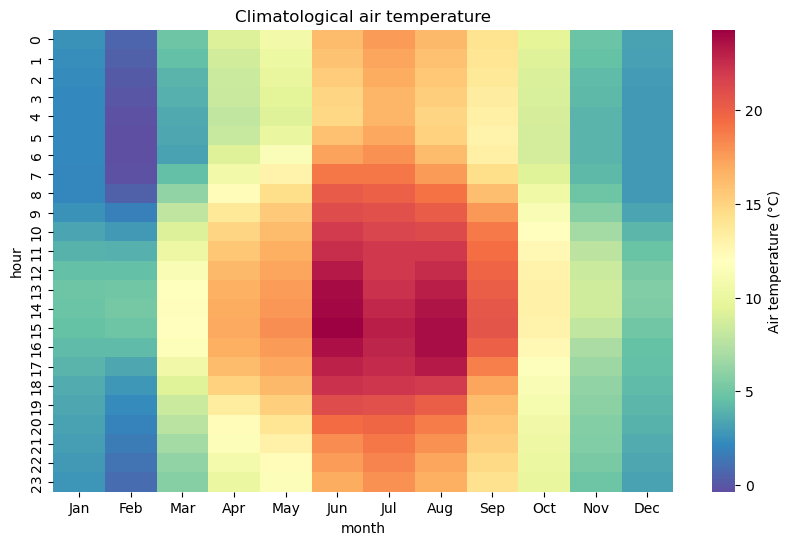

In [22]:
df = pd.read_csv(fn)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
df["month"] = df["time"].dt.month
df["hour"] = df["time"].dt.hour

climatology = df.pivot_table(
    values=HOSTRADA_VAR,
    index="hour",
    columns="month",
    aggfunc="mean")

plt.figure(figsize=(10,6))
plt.xlabel("Month")
plt.ylabel("Hour")

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

if HOSTRADA_VAR == "tas":
    lable = "Air temperature (°C)"
elif HOSTRADA_VAR == "uhi":
    lable = "Urban Heat Island Intensity (°C)"
elif HOSTRADA_VAR == "sfcWind":
    lable = "wind speed (m/s)"
elif HOSTRADA_VAR == "rsda":
    lable = "global radiation (W/m2)"
elif HOSTRADA_VAR == "clt":
    lable = "cloud cover (eighth)"
elif HOSTRADA_VAR == "hurs":
    lable = "relative humidity (percent)"
elif HOSTRADA_VAR == "tdew":
    lable = "dew point temperature (°C)"
else:
    lable = "unknown"

sns.heatmap(
    climatology,
    #cmap="coolwarm",
    cmap="Spectral_r",
    xticklabels=months,
    cbar_kws={"label": lable}
)

if HOSTRADA_VAR == "tas":
    title = "Climatological air temperature"
elif HOSTRADA_VAR == "uhi":
    title = "Climatological Urban Heat Island Intensity"
elif HOSTRADA_VAR == "sfcWind":
    title = "Climatological wind speed"
elif HOSTRADA_VAR == "rsds":
    title = "Climatological global radiation"
elif HOSTRADA_VAR == "clt":
    title = "Climatological cloud cover"
elif HOSTRADA_VAR == "clt":    
    title = "Climatological relative Feuchte"
elif HOSTRADA_VAR == "tdew":
    title = "Climatological dew point temperature"
else:
    title = "unknown"

plt.title(title)
plt.show()
